In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# Cargar datos
df = pd.read_csv('../datos/procesados/probabilidades_campeon.csv')
df = df.sort_values('probabilidad', ascending=False).reset_index(drop=True)
ranking_elo = pd.read_csv('../datos/procesados/ranking_elo.csv')

N = df['victorias'].sum()

# Estilo
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
})

# Función de color (usada en todas las gráficas)
def color_tier(p):
    if p >= 10: return '#C0392B'
    if p >=  5: return '#2980B9'
    return             '#7F8C8D'

print(f"✅ Datos listos — {N} simulaciones, {len(df)} equipos")
print(df.head(5).to_string(index=False))

✅ Datos listos — 1000 simulaciones, 33 equipos
seleccion  victorias  probabilidad
    Spain        105          10.5
  Morocco        102          10.2
    Japan         96           9.6
Australia         61           6.1
  England         59           5.9


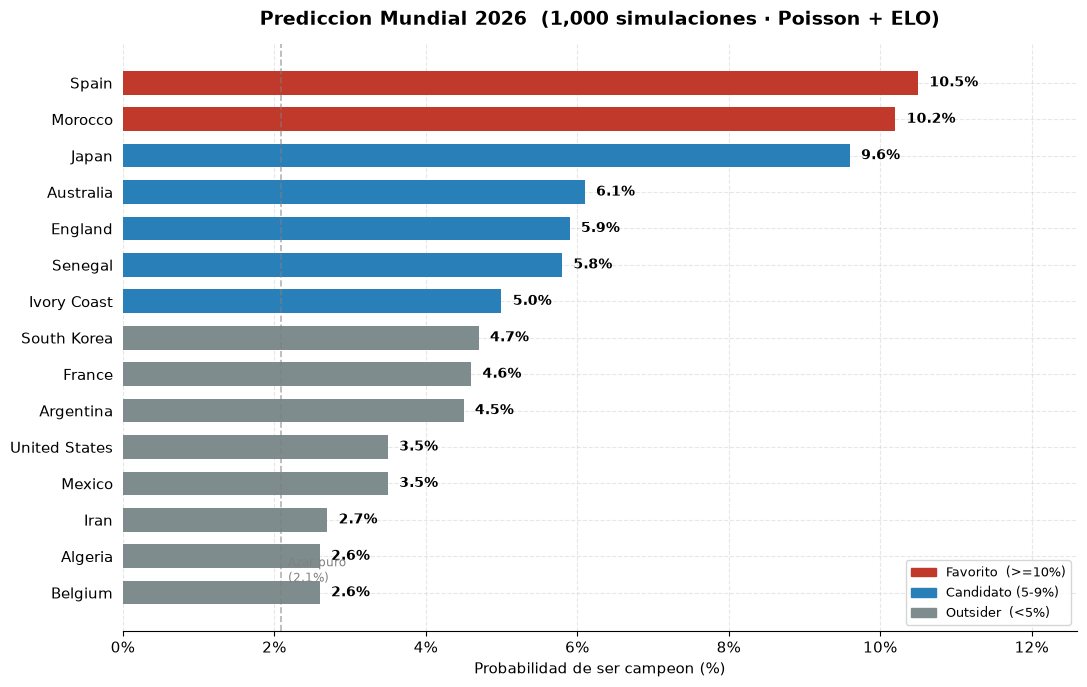

✅ Guardado: prediccion_mundial2026.png


In [6]:
top = df.head(15).sort_values('probabilidad')
colores = [color_tier(p) for p in top['probabilidad']]
azar = 100 / 48

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top['seleccion'], top['probabilidad'], color=colores, height=0.65, zorder=2)

for bar, val in zip(bars, top['probabilidad']):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.axvline(azar, color='gray', linestyle='--', alpha=0.6, linewidth=1.2)
ax.text(azar + 0.1, 0.3, f'Azar puro\n({azar:.1f}%)', color='gray', fontsize=8.5)

leyenda = [
    mpatches.Patch(color='#C0392B', label='Favorito  (>=10%)'),
    mpatches.Patch(color='#2980B9', label='Candidato (5-9%)'),
    mpatches.Patch(color='#7F8C8D', label='Outsider  (<5%)'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)
ax.set_xlabel('Probabilidad de ser campeon (%)')
ax.set_title(f'Prediccion Mundial 2026  ({N:,} simulaciones · Poisson + ELO)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlim(0, top['probabilidad'].max() * 1.2)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig('../datos/procesados/prediccion_mundial2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado: prediccion_mundial2026.png")

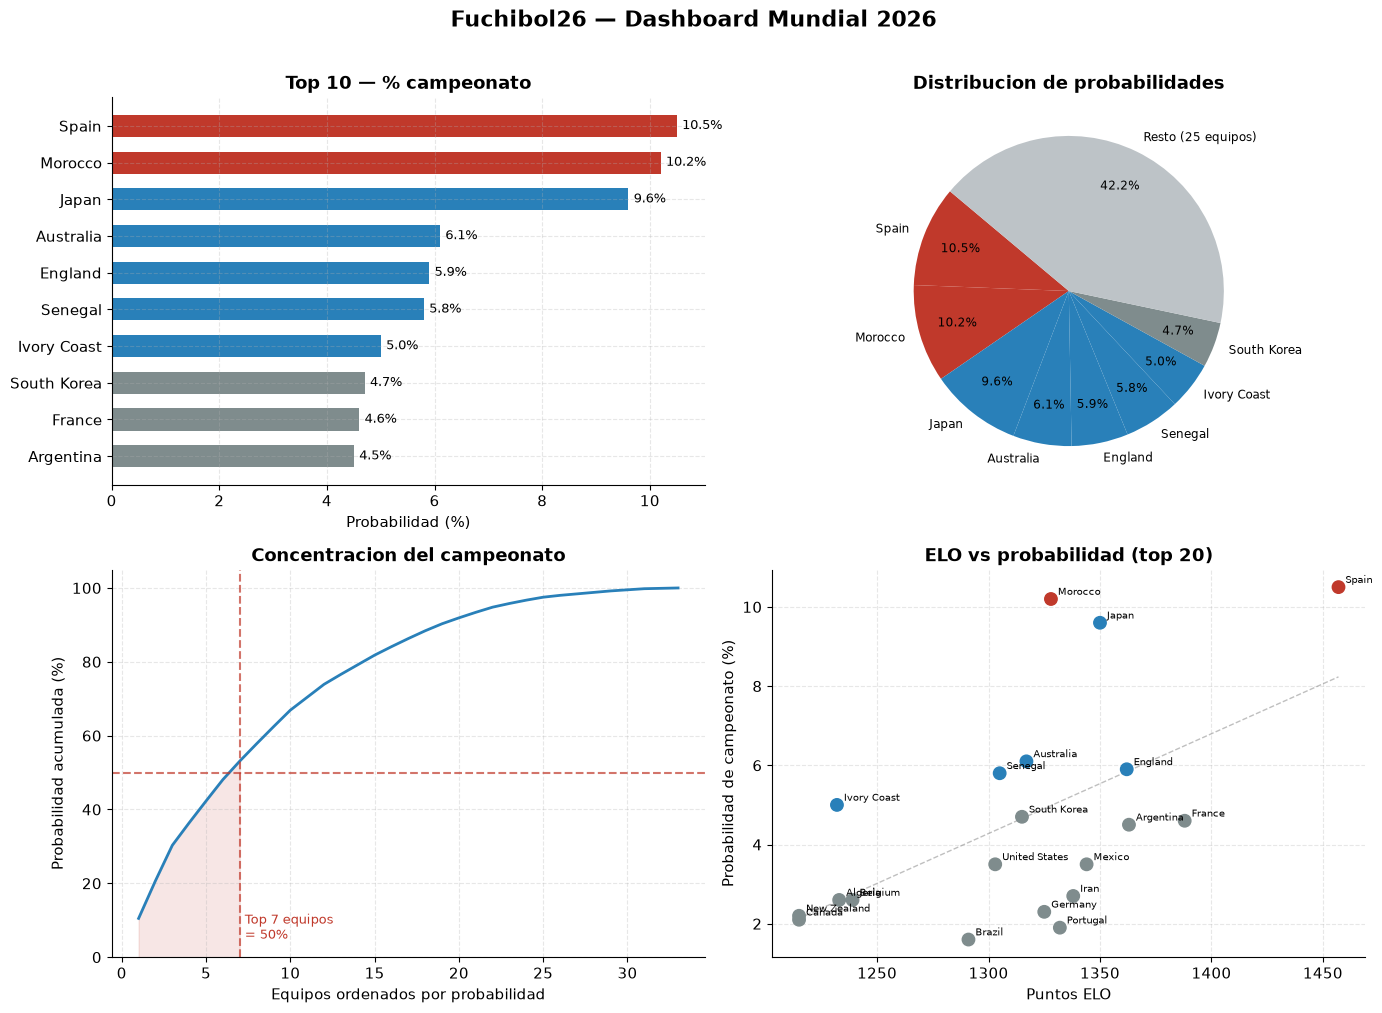

✅ Guardado: dashboard_mundial2026.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fuchibol26 — Dashboard Mundial 2026', fontsize=16, fontweight='bold', y=1.01)

# Panel A: Top 10
ax = axes[0, 0]
t10 = df.head(10).sort_values('probabilidad')
ax.barh(t10['seleccion'], t10['probabilidad'],
        color=[color_tier(p) for p in t10['probabilidad']], height=0.6)
for i, (_, row) in enumerate(t10.iterrows()):
    ax.text(row['probabilidad']+0.1, i, f"{row['probabilidad']:.1f}%", va='center', fontsize=9)
ax.set_title('Top 10 — % campeonato', fontweight='bold')
ax.set_xlabel('Probabilidad (%)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel B: Pie top 8 vs resto
ax = axes[0, 1]
top8  = df.head(8)
resto = pd.DataFrame([{'seleccion': f'Resto ({len(df)-8} equipos)',
                        'probabilidad': df.iloc[8:]['probabilidad'].sum()}])
pie_df = pd.concat([top8, resto], ignore_index=True)
ax.pie(pie_df['probabilidad'], labels=pie_df['seleccion'],
       colors=[color_tier(p) for p in top8['probabilidad']] + ['#BDC3C7'],
       autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
       startangle=140, pctdistance=0.75, textprops={'fontsize': 8.5})
ax.set_title('Distribucion de probabilidades', fontweight='bold')

# Panel C: Probabilidad acumulada
ax = axes[1, 0]
df_cum = df.copy()
df_cum['acum'] = df_cum['probabilidad'].cumsum()
corte50 = (df_cum['acum'] <= 50).sum() + 1
ax.plot(range(1, len(df_cum)+1), df_cum['acum'], color='#2980B9', linewidth=2)
ax.axhline(50, color='#C0392B', linestyle='--', alpha=0.7)
ax.axvline(corte50, color='#C0392B', linestyle='--', alpha=0.7)
ax.text(corte50+0.3, 5, f'Top {corte50} equipos\n= 50%', color='#C0392B', fontsize=9)
ax.fill_between(range(1, corte50+1), df_cum['acum'].iloc[:corte50], alpha=0.12, color='#C0392B')
ax.set_xlabel('Equipos ordenados por probabilidad')
ax.set_ylabel('Probabilidad acumulada (%)')
ax.set_title('Concentracion del campeonato', fontweight='bold')
ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel D: ELO vs probabilidad
ax = axes[1, 1]
merged = df.merge(ranking_elo[['seleccion','puntos_elo']], on='seleccion', how='left')
merged = merged.dropna(subset=['puntos_elo']).head(20)
ax.scatter(merged['puntos_elo'], merged['probabilidad'],
           c=[color_tier(p) for p in merged['probabilidad']], s=80, zorder=3)
for _, row in merged.iterrows():
    ax.annotate(row['seleccion'], (row['puntos_elo'], row['probabilidad']),
                textcoords='offset points', xytext=(5,3), fontsize=7.5)
z = np.polyfit(merged['puntos_elo'], merged['probabilidad'], 1)
xs = np.linspace(merged['puntos_elo'].min(), merged['puntos_elo'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), '--', color='gray', alpha=0.5, linewidth=1)
ax.set_xlabel('Puntos ELO')
ax.set_ylabel('Probabilidad de campeonato (%)')
ax.set_title('ELO vs probabilidad (top 20)', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../datos/procesados/dashboard_mundial2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado: dashboard_mundial2026.png")

In [8]:
# Grupos REALES del Mundial 2026 — sorteo oficial 5 dic 2025
grupos = {
    'A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curacao', 'Ivory Coast', 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

# Verificar nombres contra tus datos ELO
print("=== Equipos NO encontrados en ELO ===")
faltantes = []
for grupo, equipos in grupos.items():
    for e in equipos:
        if e not in elo:
            faltantes.append(e)
            print(f"  ⚠ Grupo {grupo}: '{e}'")

if not faltantes:
    print("  ✅ Todos encontrados")
else:
    print(f"\nTotal faltantes: {len(faltantes)}")
    print("Busca cómo se llaman en tus datos:")
    nombres = list(elo.keys())
    buscar = ['South Africa', 'Czech', 'Bosnia', 'Qatar', 'Haiti',
              'Scotland', 'Curacao', 'Cape Verde', 'Iraq', 'Jordan',
              'Uzbekistan', 'Ghana']
    for b in buscar:
        matches = [n for n in nombres if b.lower() in n.lower()]
        if matches: print(f"  '{b}' → {matches}")

=== Equipos NO encontrados en ELO ===
  ⚠ Grupo E: 'Curacao'

Total faltantes: 1
Busca cómo se llaman en tus datos:
  'South Africa' → ['South Africa']
  'Czech' → ['Czechoslovakia', 'Czech Republic']
  'Bosnia' → ['Bosnia and Herzegovina']
  'Qatar' → ['Qatar']
  'Haiti' → ['Haiti']
  'Scotland' → ['Scotland']
  'Cape Verde' → ['Cape Verde']
  'Iraq' → ['Iraq']
  'Jordan' → ['Jordan']
  'Uzbekistan' → ['Uzbekistan']
  'Ghana' → ['Ghana']
